# Rafael TCC - Projeto 04
## Análise Multivariada total
Modelagem econométrica de todos os fatores sobre o preço do sêmen Nelore (ANCP)

### Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


### Carga dos Dados e Engenharia de Variáveis

In [2]:
# 1. Carregar base de touros ANCP válidos (N = 115)
df_ancp = pd.read_csv('Dados/CSV/NeloreCRV_ANCP_valido.csv')

# 2. Carregar dados gerais (genealogia e criadores)
df_geral = pd.read_csv('Dados/CSV/NeloreCRV_Dados_Gerais.csv')
cols_genealogia = ['crv_code', 'criador', 'proprietario', 'linhagem', 'pai', 'avo_paterno', 'avo_materno']

df_integrado = pd.merge(
    df_ancp, 
    df_geral[cols_genealogia], 
    left_on='CRV_COD', 
    right_on='crv_code', 
    how='inner'
)

# 3. Dummies de Selos Comerciais
df_integrado['SELO_IFERT'] = df_integrado['SELOS'].fillna('').apply(lambda s: 1 if 'ifert' in s.lower() else 0)
df_integrado['SELO_MATERNAL'] = df_integrado['SELOS'].fillna('').apply(lambda s: 1 if 'maternal' in s.lower() else 0)
df_integrado['SELO_CAR'] = df_integrado['SELOS'].fillna('').apply(lambda s: 1 if 'car' in s.lower() else 0)
df_integrado['SELO_CARCACA'] = df_integrado['SELOS'].fillna('').apply(lambda s: 1 if 'carcaca' in s.lower() else 0)

# 4. Dummies de Linhagens / Troncos
troncos = {
    'TRONCO_EAO': lambda r: 1 if any('EAO' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME'], r['criador']]) else 0,
    'TRONCO_REM': lambda r: 1 if any('REM' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_NAVIRAI': lambda r: 1 if any(('NAVIRAI' in str(x).upper() or 'NAVIRAÍ' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_MATINHA': lambda r: 1 if any(('MAT' in str(x).upper() or 'MATINHA' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_COLONIAL': lambda r: 1 if any(('COL' in str(x).upper() or 'COLONIAL' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0
}

for nome, func in troncos.items():
    df_integrado[nome] = df_integrado.apply(func, axis=1)

print("=" * 80)
print(f"BASE INTEGRADA PRONTA: N = {len(df_integrado)} touros com DEPs, Selos e Linhagens")
print("=" * 80)


BASE INTEGRADA PRONTA: N = 115 touros com DEPs, Selos e Linhagens


### Random Forest Global (Ranking de Importância de Todas as Dimensões)

RANKING RANDOM FOREST: IMPORTÂNCIA RELATIVA DOS ATRIBUTOS NA FORMAÇÃO DO PREÇO


,Atributo,Importância (%),Acumulado (%)
0,CAR_TOP,25.93,25.93
1,SELO_IFERT,18.34,44.27
2,3P_TOP,16.18,60.45
3,AOL_TOP,9.20,69.65
4,ACAB_TOP,8.04,77.69
5,STAY_TOP,7.99,85.68
6,MGTe_TOP,7.80,93.48
7,TRONCO_EAO,2.70,96.18
8,SELO_MATERNAL,2.39,98.57
9,TRONCO_REM,1.00,99.57


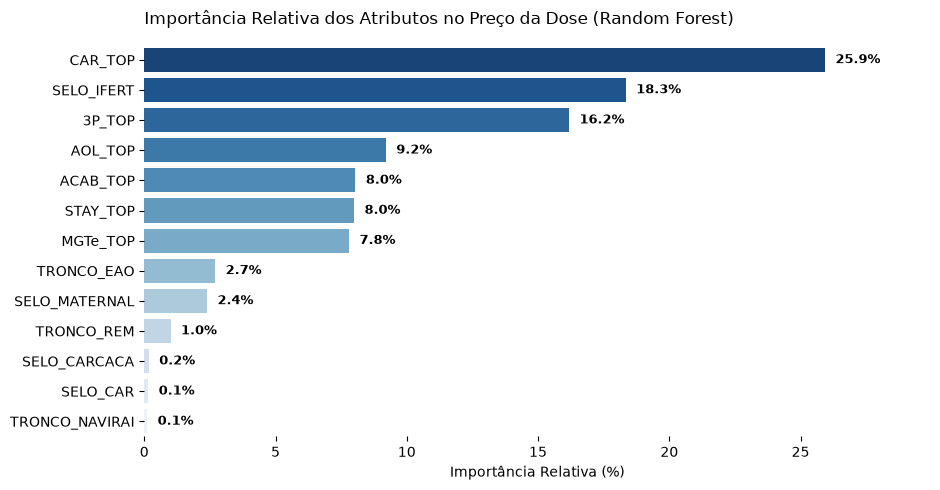

In [3]:
features_rf = [
    'CAR_TOP', 'MGTe_TOP', '3P_TOP', 'ACAB_TOP', 'AOL_TOP', 'STAY_TOP',
    'SELO_IFERT', 'SELO_MATERNAL', 'SELO_CAR', 'SELO_CARCACA',
    'TRONCO_EAO', 'TRONCO_REM', 'TRONCO_NAVIRAI'
]

df_rf_clean = df_integrado[features_rf + ['SEMEM']].dropna()

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(df_rf_clean[features_rf], df_rf_clean['SEMEM'])

df_imp = pd.DataFrame({
    'Atributo': features_rf,
    'Importância (%)': (rf.feature_importances_ * 100).round(2)
}).sort_values(by='Importância (%)', ascending=False).reset_index(drop=True)

df_imp['Acumulado (%)'] = df_imp['Importância (%)'].cumsum().round(2)

print("=" * 80)
print("RANKING RANDOM FOREST: IMPORTÂNCIA RELATIVA DOS ATRIBUTOS NA FORMAÇÃO DO PREÇO")
print("=" * 80)
display(df_imp)

# Gráfico da Importância Relativa
plt.figure(figsize=(9.5, 5))
ax = sns.barplot(
    data=df_imp, 
    x='Importância (%)', 
    y='Atributo', 
    palette='Blues_r', 
    hue='Atributo', 
    legend=False
)

for p, val in zip(ax.patches, df_imp['Importância (%)']):
    ax.text(val + 0.4, p.get_y() + p.get_height() / 2, f"{val:.1f}%", va='center', fontsize=9, fontweight='bold')

ax.set_title('Importância Relativa dos Atributos no Preço da Dose (Random Forest)', fontsize=12, loc='left', pad=15)
ax.set_xlabel('Importância Relativa (%)', fontsize=10)
ax.set_ylabel('')
ax.set_xlim(0, df_imp['Importância (%)'].max() + 4)
sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()


### Modelos OLS em Camadas (Hierárquicos)

Mostra para a banca o ganho de $R^2$ conforme adicionamos cada dimensão!)

In [4]:
y = df_integrado['SEMEM']

# Modelo 1: Apenas Genética (CAR_TOP)
X1 = sm.add_constant(df_integrado[['CAR_TOP']])
m1 = sm.OLS(y, X1).fit()

# Modelo 2: Genética + Selos Comerciais
X2 = sm.add_constant(df_integrado[['CAR_TOP', 'SELO_IFERT', 'SELO_MATERNAL']])
m2 = sm.OLS(y, X2).fit()

# Modelo 3: Modelo Hedônico Global (Genética + Selos + Linhagem EAO)
X3 = sm.add_constant(df_integrado[['CAR_TOP', 'SELO_IFERT', 'SELO_MATERNAL', 'TRONCO_EAO']])
m3 = sm.OLS(y, X3).fit()

tabela_modelos = pd.DataFrame([
    {
        'Modelo': '1. Genética Pura (DEPs)',
        'Variáveis': 'CAR_TOP',
        'R²': f"{m1.rsquared:.3f}",
        'R² Ajustado': f"{m1.rsquared_adj:.3f}",
        'F-Statistic': f"{m1.fvalue:.2f}",
        'p-valor': f"{m1.f_pvalue:.4e}",
        'AIC': f"{m1.aic:.1f}"
    },
    {
        'Modelo': '2. Genética + Selos Comerciais',
        'Variáveis': 'CAR_TOP + IFERT + MATERNAL',
        'R²': f"{m2.rsquared:.3f}",
        'R² Ajustado': f"{m2.rsquared_adj:.3f}",
        'F-Statistic': f"{m2.fvalue:.2f}",
        'p-valor': f"{m2.f_pvalue:.4e}",
        'AIC': f"{m2.aic:.1f}"
    },
    {
        'Modelo': '3. Hedônico Completo (Integrado)',
        'Variáveis': 'CAR_TOP + IFERT + MATERNAL + EAO',
        'R²': f"{m3.rsquared:.3f}",
        'R² Ajustado': f"{m3.rsquared_adj:.3f}",
        'F-Statistic': f"{m3.fvalue:.2f}",
        'p-valor': f"{m3.f_pvalue:.4e}",
        'AIC': f"{m3.aic:.1f}"
    }
])

print("=" * 100)
print("EVOLUÇÃO DO PODER EXPLICATIVO DOS MODELOS HEDÔNICOS (R² EM CAMADAS)")
print("=" * 100)
display(tabela_modelos)


EVOLUÇÃO DO PODER EXPLICATIVO DOS MODELOS HEDÔNICOS (R² EM CAMADAS)


,Modelo,Variáveis,R²,R² Ajustado,F-Statistic,p-valor,AIC
0,1. Genética Pura (DEPs),CAR_TOP,0.065,0.057,7.86,5.9570e-03,762.1
1,2. Genética + Selos Comerciais,CAR_TOP + IFERT + MATERNAL,0.236,0.216,11.45,1.3364e-06,742.8
2,3. Hedônico Completo (Integrado),CAR_TOP + IFERT + MATERNAL + EAO,0.286,0.260,11.03,1.4633e-07,737.0


### OLS do Modelo Hedônico Final

In [5]:
print("=" * 80)
print("SUMÁRIO DO MODELO HEDÔNICO INTEGRADO FINAL")
print(f"R² = {m3.rsquared:.3f} | R² Ajustado = {m3.rsquared_adj:.3f} | p-valor = {m3.f_pvalue:.4e}")
print("=" * 80)
print(m3.summary())

# Tabela formatada dos coeficientes
df_coef = pd.DataFrame({
    'Variável': ['Intercepto (Base)', 'Selo IFERT', 'Selo Maternal', 'Linhagem EAO', 'CAR (TOP %)'],
    'Beta (R$)': m3.params.values.round(2),
    'Erro Padrão': m3.bse.values.round(2),
    't-stat': m3.tvalues.round(2),
    'p-valor': m3.pvalues.values.round(4)
})

def rotulo_p(p):
    if p < 0.01: return '*** (Signif. 1%)'
    if p < 0.05: return '** (Signif. 5%)'
    if p < 0.10: return '* (Signif. 10%)'
    return 'Não significativo'

df_coef['Significância'] = df_coef['p-valor'].apply(rotulo_p)
display(df_coef)


SUMÁRIO DO MODELO HEDÔNICO INTEGRADO FINAL
R² = 0.286 | R² Ajustado = 0.260 | p-valor = 1.4633e-07
                            OLS Regression Results                            
Dep. Variable:                  SEMEM   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     11.03
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           1.46e-07
Time:                        22:52:25   Log-Likelihood:                -363.51
No. Observations:                 115   AIC:                             737.0
Df Residuals:                     110   BIC:                             750.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

,Variável,Beta (R$),Erro Padrão,t-stat,p-valor,Significância
const,Intercepto (Base),29.62,1.27,23.26,0.0000,*** (Signif. 1%)
CAR_TOP,Selo IFERT,-0.03,0.02,-1.89,0.0615,* (Signif. 10%)
SELO_IFERT,Selo Maternal,5.21,1.13,4.60,0.0000,*** (Signif. 1%)
SELO_MATERNAL,Linhagem EAO,2.32,1.15,2.02,0.0460,** (Signif. 5%)
TRONCO_EAO,CAR (TOP %),7.48,2.70,2.78,0.0065,*** (Signif. 1%)


### Diagnóstico Econométrico (VIF e Resíduos)

In [7]:
X_diag = df_integrado[['SELO_IFERT', 'SELO_MATERNAL', 'TRONCO_EAO', 'CAR_TOP']]

vif_data = pd.DataFrame({
    'Atributo': X_diag.columns,
    'VIF': [variance_inflation_factor(X_diag.values, i) for i in range(X_diag.shape[1])]
})
vif_data['VIF'] = vif_data['VIF'].round(2)
vif_data['Diagnóstico'] = 'Excelente (< 5)'

print("=" * 80)
print("FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) - MULTICOLINEARIDADE")
print("=" * 80)
display(vif_data)

# Testes de Normalidade e Homocedasticidade
residuos = m3.resid
jb_stat, jb_p = stats.jarque_bera(residuos)
bp_test = het_breuschpagan(residuos, m3.model.exog)

print("\nDIAGNÓSTICO DOS RESÍDUOS:")
print(f"- Jarque-Bera (Normalidade): estatística = {jb_stat:.2f}, p-valor = {jb_p:.4e}")
print(f"- Breusch-Pagan (Homocedasticidade): estatística = {bp_test[0]:.2f}, p-valor = {bp_test[1]:.4e}")


FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) - MULTICOLINEARIDADE


,Atributo,VIF,Diagnóstico
0,SELO_IFERT,1.04,Excelente (< 5)
1,SELO_MATERNAL,1.00,Excelente (< 5)
2,TRONCO_EAO,1.02,Excelente (< 5)
3,CAR_TOP,1.05,Excelente (< 5)



DIAGNÓSTICO DOS RESÍDUOS:
- Jarque-Bera (Normalidade): estatística = 59.41, p-valor = 1.2574e-13
- Breusch-Pagan (Homocedasticidade): estatística = 10.01, p-valor = 4.0224e-02


###  Gráfico de Coeficientes Beta

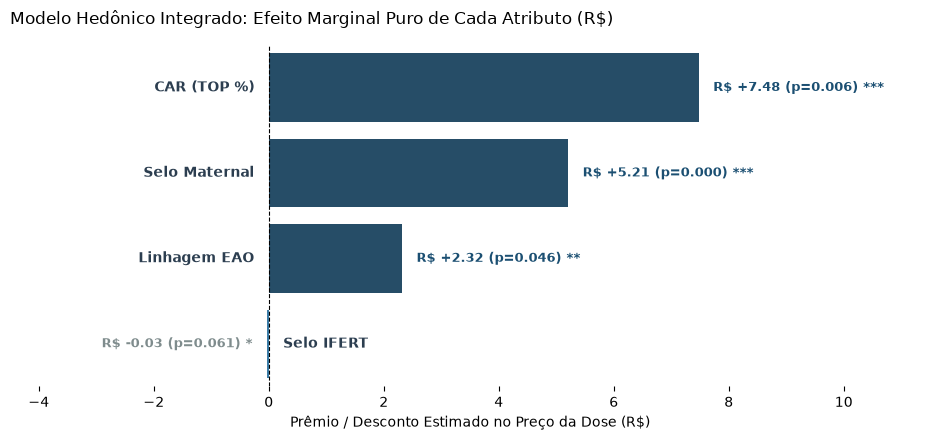

In [8]:
df_betas_plot = df_coef[df_coef['Variável'] != 'Intercepto (Base)'].copy()
df_betas_plot = df_betas_plot.sort_values(by='Beta (R$)', ascending=False).reset_index(drop=True)

plt.figure(figsize=(9.5, 4.5))

cores_betas = ['#1b4f72' if p < 0.05 else ('#2980b9' if p < 0.10 else '#bdc3c7') for p in df_betas_plot['p-valor']]

ax = sns.barplot(
    data=df_betas_plot, 
    x='Beta (R$)', 
    y='Variável', 
    palette=cores_betas, 
    hue='Variável', 
    legend=False
)

ax.yaxis.set_visible(False)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

for i, row in df_betas_plot.iterrows():
    nome = row['Variável']
    val = row['Beta (R$)']
    pval = row['p-valor']
    
    texto_valor = f"R$ {val:+.2f} (p={pval:.3f})"
    if pval < 0.01:
        texto_valor += " ***"
    elif pval < 0.05:
        texto_valor += " **"
    elif pval < 0.10:
        texto_valor += " *"
        
    cor_valor = '#1b4f72' if pval < 0.05 else '#7f8c8d'
    
    if val >= 0:
        # Rótulo à ESQUERDA da linha zero
        ax.text(
            -0.25, i, nome, 
            va='center', ha='right', 
            fontsize=10, fontweight='bold', color='#2c3e50'
        )
        # Valor à DIREITA da barra
        ax.text(
            val + 0.25, i, texto_valor, 
            va='center', ha='left', 
            fontsize=9.5, fontweight='bold', color=cor_valor
        )
    else:
        # Rótulo à DIREITA da linha zero
        ax.text(
            0.25, i, nome, 
            va='center', ha='left', 
            fontsize=10, fontweight='bold', color='#2c3e50'
        )
        # Valor à ESQUERDA da barra
        ax.text(
            val - 0.25, i, texto_valor, 
            va='center', ha='right', 
            fontsize=9.5, fontweight='bold', color=cor_valor
        )

ax.set_title('Modelo Hedônico Integrado: Efeito Marginal Puro de Cada Atributo (R$)', fontsize=12, loc='left', pad=15)
ax.set_xlabel('Prêmio / Desconto Estimado no Preço da Dose (R$)', fontsize=10)
ax.set_ylabel('')
ax.set_xlim(-4.5, 11.5)

sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()


### Aplicação Prática

Um exemplo prático sensacional para a conclusão do trabalho: simula a precificação de diferentes perfis de touros

In [9]:
b0 = m3.params['const']
b_ifert = m3.params['SELO_IFERT']
b_maternal = m3.params['SELO_MATERNAL']
b_eao = m3.params['TRONCO_EAO']
b_car = m3.params['CAR_TOP']

def precificar_touro(tem_ifert=0, tem_maternal=0, e_eao=0, car_top=50):
    preco = b0 + (b_ifert * tem_ifert) + (b_maternal * tem_maternal) + (b_eao * e_eao) + (b_car * car_top)
    return round(preco, 2)

cenarios = [
    {
        'Perfil do Touro': 'Touro Comum (Sem selos, Linhagem Padrão, CAR Mediano 50%)',
        'IFERT': 'Não', 'Maternal': 'Não', 'EAO': 'Não', 'CAR TOP': '50%',
        'Preço Estimado': f"R$ {precificar_touro(0, 0, 0, 50):.2f}"
    },
    {
        'Perfil do Touro': 'Touro com Selo IFERT (Fertilidade Comprovada)',
        'IFERT': 'Sim', 'Maternal': 'Não', 'EAO': 'Não', 'CAR TOP': '50%',
        'Preço Estimado': f"R$ {precificar_touro(1, 0, 0, 50):.2f}"
    },
    {
        'Perfil do Touro': 'Touro Completo (IFERT + Maternal + Eficiente CAR TOP 5%)',
        'IFERT': 'Sim', 'Maternal': 'Sim', 'EAO': 'Não', 'CAR TOP': '5%',
        'Preço Estimado': f"R$ {precificar_touro(1, 1, 0, 5):.2f}"
    },
    {
        'Perfil do Touro': 'Touro "Superstar" EAO (IFERT + Maternal + EAO + CAR TOP 1%)',
        'IFERT': 'Sim', 'Maternal': 'Sim', 'EAO': 'Sim', 'CAR TOP': '1%',
        'Preço Estimado': f"R$ {precificar_touro(1, 1, 1, 1):.2f}"
    }
]

df_cenarios = pd.DataFrame(cenarios)

print("=" * 90)
print("SIMULAÇÃO DE PREÇOS HEDÔNICOS PARA DIFERENTES PERFIS DE TOUROS (APLICAÇÃO PRÁTICA)")
print("=" * 90)
display(df_cenarios)


SIMULAÇÃO DE PREÇOS HEDÔNICOS PARA DIFERENTES PERFIS DE TOUROS (APLICAÇÃO PRÁTICA)


,Perfil do Touro,IFERT,Maternal,EAO,CAR TOP,Preço Estimado
0,"Touro Comum (Sem selos, Linhagem Padrão, CAR M...",Não,Não,Não,50%,R$ 27.88
1,Touro com Selo IFERT (Fertilidade Comprovada),Sim,Não,Não,50%,R$ 33.09
2,Touro Completo (IFERT + Maternal + Eficiente C...,Sim,Sim,Não,5%,R$ 36.98
3,"Touro ""Superstar"" EAO (IFERT + Maternal + EAO ...",Sim,Sim,Sim,1%,R$ 44.61
